# Pupil extraction

This notebook runs the pupil pipeline in three stages: strict clock/count validation, a sparse session-wide segmentation QC montage, and the full streaming extraction. The full pass is intentionally not started if the decoded video count and `cameraFrameSync` pulse count disagree. Camera timing comes directly from the shared-clock sync HDF5; no separate frametimes CSV is needed.

In [21]:
from pathlib import Path
from dataclasses import replace
import importlib, os, sys

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

# Works when the notebook is opened from either the repository root or analysis/.
REPO = Path.cwd().resolve()
if not (REPO / 'analysis').is_dir():
    REPO = REPO.parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import analysis.session.pupil as pupil_module
pupil_module = importlib.reload(pupil_module)

from analysis.session.pupil import (
    PupilConfig, count_csv_frames, count_video_frames,
    extract_pupil, fit_pupil_mask, iter_gray_frames, order_pupil_videos,
    stage_pupil_videos, stage_sync_file, launch_pupil_tuner, load_pupil_tuning,
    segment_bright_pupil, validate_alignment_counts,
)
from analysis.session.respiration import find_behavior_sync
from analysis.session.sync import frame_onset_samples, open_sync
from analysis.session.devshim import LocalGroup
from analysis.session.resolve import resolve_group


## Configuration

Set `GROUP_ID`. The group supplies acquisition IDs, odor timing, and states; no segmentation or trace round is required. Under the experiment, the resolver expects exactly two pupil recordings somewhere below `video/`, each with a `converted/` directory containing one MP4. The earlier recording is pre and the later recording is post. `ROI` is `(y0, y1, x0, x1)` and should tightly contain the eye.

In [22]:
# ---- what to run -------------------------------------------------------
GROUP_ID = 217
MANIPULATION = 'ketxyl'
APPROVED_ONLY = False
STAGE_VIDEO_LOCALLY = True  # strongly recommended for SMB/network storage
STAGE_SYNC_LOCALLY = True   # avoids scanning cameraFrameSync over SMB

SCRATCH = Path(os.environ.get('ODYN_SCRATCH_ROOT', str(Path.home() / 'odyn_scratch')))
SCRATCH.mkdir(parents=True, exist_ok=True)
MAIN = Path(os.environ.get('ODYN_IMAGING_ROOT', '/Volumes/MossLab/ImagingData'))
LIVE_DB = MAIN / '.odyn' / 'odyn.db'
SNAPSHOT = SCRATCH / 'odyn_snapshot.db'

group = LocalGroup(LIVE_DB, MAIN, snapshot_to=SNAPSHOT, refresh=True)
session = resolve_group(
    group, group_id=GROUP_ID, manipulation=MANIPULATION,
    approved_only=APPROVED_ONLY,
)

OUT_DIR = session.output_dir / 'aux'

# Discover <experiment>/video/<pre-or-post-pupil>/converted/<movie>.
video_roots = [p for name in ('video', 'videos') if (p := session.exp_dir / name).is_dir()]
video_roots += sorted(p for p in session.exp_dir.glob('*_video') if p.is_dir())
video_roots = list(dict.fromkeys(video_roots))
if not video_roots:
    raise FileNotFoundError(
        f'No video/, videos/, or <experiment>_video directory under {session.exp_dir}'
    )
converted_dirs = sorted({p for root in video_roots for p in root.rglob('converted') if p.is_dir()})
discovered_mp4s = []
for converted in converted_dirs:
    mp4s = sorted(converted.glob('*.mp4'))
    if len(mp4s) != 1:
        continue
    discovered_mp4s.append(mp4s[0])

if len(discovered_mp4s) != 2:
    found = [str(p.relative_to(session.exp_dir)) for p in converted_dirs]
    raise FileNotFoundError(
        'Expected exactly two pupil folders, each containing converted/<one mp4>. '
        f'Found MP4s: {[str(p) for p in discovered_mp4s]}; converted folders: {found}'
    )
SERVER_VIDEO_PATHS, VIDEO_STAMPS = order_pupil_videos(discovered_mp4s)
VIDEO_STAGE_DIR = SCRATCH / 'pupil_video_cache' / f'group{GROUP_ID}'
VIDEO_PATHS = (stage_pupil_videos(SERVER_VIDEO_PATHS, VIDEO_STAGE_DIR)
               if STAGE_VIDEO_LOCALLY else SERVER_VIDEO_PATHS)
SYNC_PATH = None  # auto-discovered from the group experiment directory

print(f'group:       {GROUP_ID} ({session.exp_name})')
for state, server_path, path, (stamp, source) in zip(
    ('pre', 'post'), SERVER_VIDEO_PATHS, VIDEO_PATHS, VIDEO_STAMPS
):
    print(f'{state:5s} source: {server_path.relative_to(session.exp_dir)}')
    print(f'      decode: {path}')
    print(f'             {stamp.isoformat()} ({source})')
print(f'output:      {OUT_DIR.relative_to(session.exp_dir)}')

ROI = (100, 300, 80, 280)  # group 217 starting point: (y0, y1, x0, x1)
CONFIG = PupilConfig(
    roi=ROI,
    bright_percentile=97.0,  # raises Otsu into the bright pupil tail
    ransac_residual_px=2.0,
    ransac_trials=200,
    min_inlier_fraction=0.55,
    max_residual_px=3.0,
    min_axis_ratio=0.25,
    max_diameter_rate_px_s=150.0,
    max_bad_fraction=0.20,
)

N_QC_FRAMES = 16
PUPIL_WORKERS = 6       # exact same fits, distributed across CPU cores
PUPIL_BATCH_SIZE = 128  # bounds queued image memory
PUPIL_CHECKPOINT_EVERY = 1000
PUPIL_CHECKPOINT_DIR = SCRATCH / 'pupil_checkpoints' / f'group{GROUP_ID}'

group:       217 (20260805_m426_e1)
pre   source: 20260805_m426_e1_video/pupil_video_1/converted/pupil_video_1.mp4
      decode: /Users/mosse/odyn_scratch/pupil_video_cache/group217/recording_1/pupil_video_1.mp4
             2026-08-05T12:39:41.048000-07:00 (pupil_video_1_metadata.json: mm_summary.StartTime)
post  source: 20260805_m426_e1_video/pupil_video_2/converted/pupil_video_2.mp4
      decode: /Users/mosse/odyn_scratch/pupil_video_cache/group217/recording_2/pupil_video_2.mp4
             2026-08-05T13:32:43.617000-07:00 (pupil_video_2_metadata.json: mm_summary.StartTime)
output:      processed/python/aux


## 1. Alignment preflight

This performs one streaming decode solely to obtain the exact decoded frame count. A mismatch raises immediately, before segmentation or output writing.

In [23]:
for path in VIDEO_PATHS:
    if not path.exists():
        raise FileNotFoundError(path)

server_sync_path = (Path(SYNC_PATH) if SYNC_PATH is not None
                    else find_behavior_sync(session.exp_dir))
sync_path = (stage_sync_file(server_sync_path, SCRATCH / 'pupil_sync_cache' / f'group{GROUP_ID}')
             if STAGE_SYNC_LOCALLY else server_sync_path)
print(f'sync source: {server_sync_path}')
print(f'sync read:   {sync_path}')
sync = open_sync(sync_path)
camera_samples_all = frame_onset_samples(sync, channel='cameraFrameSync')
from analysis.session.sync import group_frames_into_acquisitions
camera_blocks = group_frames_into_acquisitions(camera_samples_all, rate_hz=sync.rate_hz)
if len(camera_blocks) != 2:
    raise ValueError(f'Expected two contiguous cameraFrameSync blocks, found {len(camera_blocks)}')
video_counts = [validate_alignment_counts(path, block) for path, block in zip(VIDEO_PATHS, camera_blocks)]
n_camera = sum(video_counts)
camera_samples = np.concatenate(camera_blocks)
two_p_samples = frame_onset_samples(sync, channel='2pFrameSync')
two_p_blocks = group_frames_into_acquisitions(two_p_samples, rate_hz=sync.rate_hz)
imaging_active = np.zeros(len(camera_samples), dtype=bool)
for block in two_p_blocks:
    lo = np.searchsorted(camera_samples, block[0], side='left')
    hi = np.searchsorted(camera_samples, block[-1], side='right')
    imaging_active[lo:hi] = True
camera_time_s = camera_samples / sync.rate_hz
duration_min = (camera_time_s[-1] - camera_time_s[0]) / 60

print(f'PASS pre:  {video_counts[0]:,} decoded frames = cameraFrameSync block 1 pulses')
print(f'PASS post: {video_counts[1]:,} decoded frames = cameraFrameSync block 2 pulses')
print(f'Sync: {sync_path}')
print(f'Camera duration: {duration_min:.2f} min')
print(f'Median camera rate: {1 / np.median(np.diff(camera_time_s)):.3f} Hz')
print(f'Frames inside 2p acquisitions: {imaging_active.mean():.1%}')

sync source: /Volumes/MossLab/ImagingData/20260805/m426/m426_e1_2026-08-05_12-39-21.h5
sync read:   /Users/mosse/odyn_scratch/pupil_sync_cache/group217/m426_e1_2026-08-05_12-39-21.h5
PASS pre:  61,648 decoded frames = cameraFrameSync block 1 pulses
PASS post: 61,648 decoded frames = cameraFrameSync block 2 pulses
Sync: /Users/mosse/odyn_scratch/pupil_sync_cache/group217/m426_e1_2026-08-05_12-39-21.h5
Camera duration: 94.04 min
Median camera rate: 25.000 Hz
Frames inside 2p acquisitions: 65.0%


## 2. Tune ROI and threshold

The videos are streamed once to retain evenly spaced raw illuminated examples. The dimmest and brightest examples then open in the tuner. Set the four ROI corner sliders (`x0`, `x1`, `y0`, `y1`); the yellow rectangle is mirrored on both panels. Adjust the adaptive-threshold offset until cyan segmentation is correct on both, then save.

In [ ]:
per_video_qc = max(2, N_QC_FRAMES // 2)
raw_samples = []
offset = 0
for state, path, count in zip(('pre', 'post'), VIDEO_PATHS, video_counts):
    local_active = np.flatnonzero(imaging_active[offset:offset + count])
    if local_active.size == 0:
        raise ValueError(f'No illuminated camera frames overlap the {state} video')
    sample_indices = set(local_active[np.linspace(0, local_active.size - 1, per_video_qc, dtype=int)])
    for local_i, frame in enumerate(iter_gray_frames(path)):
        if local_i not in sample_indices:
            continue
        raw_samples.append((state, local_i, frame))
    offset += count

y0, y1, x0, x1 = CONFIG.roi or (0, raw_samples[0][2].shape[0], 0, raw_samples[0][2].shape[1])
brightness = np.array([np.mean(item[2][y0:y1, x0:x1]) for item in raw_samples])
dim_frame = raw_samples[int(np.argmin(brightness))][2]
bright_frame = raw_samples[int(np.argmax(brightness))][2]
TUNING_PATH = OUT_DIR / f'group{GROUP_ID}_{session.exp_name}_pupil_tuning.json'
tuner = launch_pupil_tuner(
    dim_frame, bright_frame, save_path=TUNING_PATH, roi=CONFIG.roi,
    threshold_offset=CONFIG.threshold_offset,
    bright_percentile=CONFIG.bright_percentile,
)

ERROR:tornado.application:Uncaught exception GET /ws?id=0650616f-0eb2-4b88-bc09-ece3b2798597&parentId=1&origin=078754f2-5f12-4292-b43e-200d36396fd2&swVersion=6&extensionId=&platform=electron&vscode-resource-base-authority=vscode-resource.vscode-cdn.net&parentOrigin=vscode-file%3A%2F%2Fvscode-app&purpose=notebookRenderer (::1)
HTTPServerRequest(protocol='http', host='localhost:65487', method='GET', uri='/ws?id=0650616f-0eb2-4b88-bc09-ece3b2798597&parentId=1&origin=078754f2-5f12-4292-b43e-200d36396fd2&swVersion=6&extensionId=&platform=electron&vscode-resource-base-authority=vscode-resource.vscode-cdn.net&parentOrigin=vscode-file%3A%2F%2Fvscode-app&purpose=notebookRenderer', version='HTTP/1.1', remote_ip='::1')
Traceback (most recent call last):
  File "/Users/mosse/miniforge3/envs/caiman/lib/python3.12/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^

After saving in the GUI, apply the settings below.

In [33]:
if not TUNING_PATH.exists():
    raise FileNotFoundError('Click Save ROI + threshold in the tuner first.')
tuning = load_pupil_tuning(TUNING_PATH)
CONFIG = replace(CONFIG, **tuning)
print('Applied:', tuning)

Applied: {'roi': (83, 318, 21, 283), 'threshold_offset': 20.0, 'bright_percentile': 97.0}


## 3. Sparse segmentation QC

The saved ROI and threshold are now applied to all retained raw examples. Cyan is the segmentation, magenta is the chord-excluded RANSAC ellipse, and the montage is saved before full extraction.

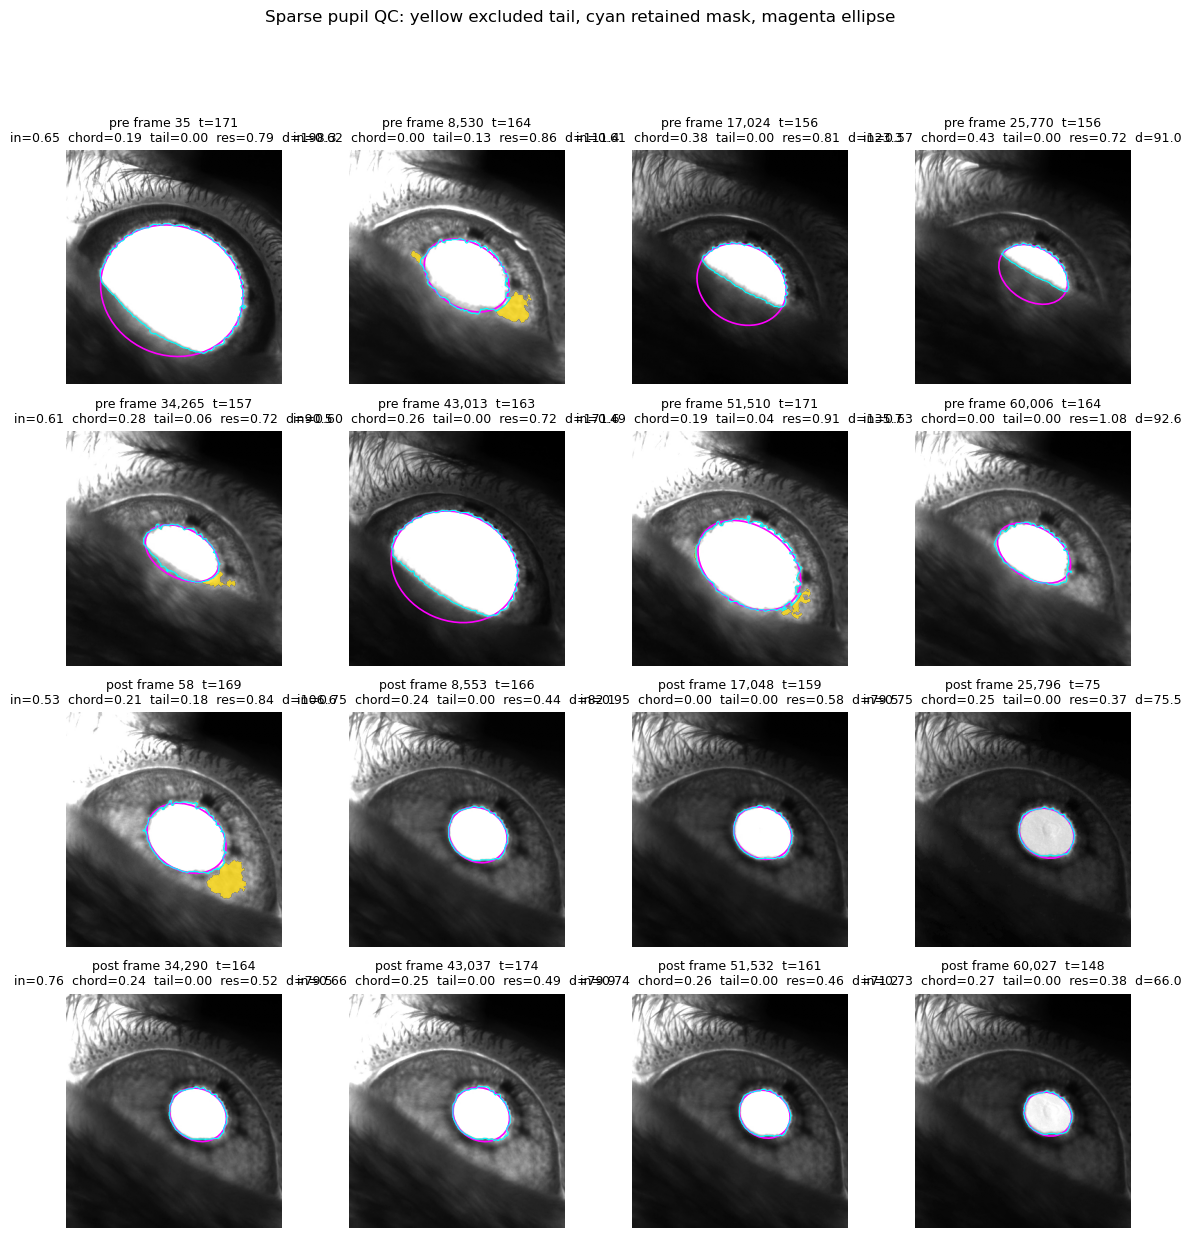

Saved: /Volumes/MossLab/ImagingData/20260805/m426/e1/processed/python/aux/group217_20260805_m426_e1_pupil_preflight_qc.png


In [34]:
samples = []
for state, local_i, frame in raw_samples:
    mask, threshold = segment_bright_pupil(
        frame, roi=CONFIG.roi, bright_percentile=CONFIG.bright_percentile,
        threshold_offset=CONFIG.threshold_offset,
    )
    cleaned, fit = fit_pupil_mask(
        mask, CONFIG, random_seed=CONFIG.random_seed + local_i,
    )
    samples.append((state, local_i, frame, mask, cleaned, threshold, fit))

n_col = 4
n_row = int(np.ceil(len(samples) / n_col))
fig, axes = plt.subplots(n_row, n_col, figsize=(14, 3.5 * n_row), squeeze=False)
for ax, item in zip(axes.flat, samples):
    state, i, frame, mask, cleaned, threshold, fit = item
    ax.imshow(frame, cmap='gray')
    excluded = mask & ~cleaned
    if np.any(excluded):
        yellow = np.zeros((*excluded.shape, 4), dtype=float)
        yellow[excluded] = (1.0, 0.85, 0.0, 0.75)
        ax.imshow(yellow)
    ax.contour(cleaned, levels=[0.5], colors='cyan', linewidths=0.8)
    if fit is not None:
        ax.add_patch(Ellipse(
            (fit['x'], fit['y']), 2 * fit['major'], 2 * fit['minor'],
            angle=np.degrees(fit['theta']), fill=False,
            edgecolor='magenta', linewidth=1.2,
        ))
        detail = (f"in={fit['inlier_fraction']:.2f}  chord={fit.get('chord_fraction', np.nan):.2f}  "
                  f"tail={fit.get('concavity_fraction', 0.0):.2f}  "
                  f"res={fit['residual']:.2f}  d={fit['diameter']:.1f}")
    else:
        detail = 'FIT FAILED'
    ax.set_title(f'{state} frame {i:,}  t={threshold:.0f}\n{detail}', fontsize=9)
    ax.axis('off')
for ax in axes.flat[len(samples):]:
    ax.axis('off')
fig.suptitle('Sparse pupil QC: yellow excluded tail, cyan retained mask, magenta ellipse')
OUT_DIR.mkdir(parents=True, exist_ok=True)
INTERMEDIATE_QC_PATH = OUT_DIR / f'group{GROUP_ID}_{session.exp_name}_pupil_preflight_qc.png'
fig.savefig(INTERMEDIATE_QC_PATH, dpi=160, bbox_inches='tight')
plt.show()
print(f'Saved: {INTERMEDIATE_QC_PATH}')

Inspect the montage now. If the cyan component is not consistently the pupil, tighten `ROI`. If thresholds drift onto sclera or background, correct the ROI or illumination before proceeding. Re-run the configuration and sparse-QC cells after changes.

## 4. Full streaming extraction

This is the long pass. It repeats the strict count preflight by design, processes one frame at a time, aligns camera frame `i` to camera pulse `i`, and samples onto the 2p frame grid using the shared clock.

In [35]:
if 'TUNING_PATH' in globals() and TUNING_PATH.exists():
    CONFIG = replace(CONFIG, **load_pupil_tuning(TUNING_PATH))
    print('Using saved pupil tuning:', load_pupil_tuning(TUNING_PATH))

report = extract_pupil(
    VIDEO_PATHS, sync_path,
    acq_ids=session.acq_ids, odor_ids=session.odor_ids, states=session.states,
    odor_on_frames=session.odor_on_frames, odor_off_frames=session.odor_off_frames,
    frame_rate=session.frame_rate, exp_name=f'group{GROUP_ID}_{session.exp_name}',
    trial_ids=session.table['trial_id'].to_numpy(),
    out_dir=OUT_DIR, config=CONFIG, save=True,
    validate_counts=False, validated_counts=video_counts,
    workers=PUPIL_WORKERS, batch_size=PUPIL_BATCH_SIZE,
    checkpoint_every=PUPIL_CHECKPOINT_EVERY,
    checkpoint_dir=PUPIL_CHECKPOINT_DIR, resume=True,
)

print(f"HDF5: {report['h5']}")
print(f"QC figure: {report['figure']}")
print(f"Trials: {report['n_trial']}, frames/trial: {report['n_frame']}")
print(f"Flagged trials: {int(report['flagged'].sum())}/{report['n_trial']}")
print(f"Median blink fraction: {np.median(report['blink_fraction']):.2%}")
print(f"Median clipping fraction: {np.median(report['clipped_fraction']):.2%}")

Using saved pupil tuning: {'roi': (83, 318, 21, 283), 'threshold_offset': 20.0, 'bright_percentile': 97.0}
Pupil fitting: 80,156 illuminated frames, 6 worker(s), 0 resumed.
  128/80,156 (0.2%) · 25.2 frames/s · ETA 53.0 min
  256/80,156 (0.3%) · 30.6 frames/s · ETA 43.5 min
  384/80,156 (0.5%) · 33.1 frames/s · ETA 40.2 min
  512/80,156 (0.6%) · 34.0 frames/s · ETA 39.1 min
  640/80,156 (0.8%) · 32.5 frames/s · ETA 40.7 min
  768/80,156 (1.0%) · 31.3 frames/s · ETA 42.3 min
  896/80,156 (1.1%) · 30.1 frames/s · ETA 43.8 min
  1,024/80,156 (1.3%) · 30.1 frames/s · ETA 43.8 min
  1,152/80,156 (1.4%) · 32.2 frames/s · ETA 40.9 min
  1,280/80,156 (1.6%) · 33.4 frames/s · ETA 39.4 min
  1,408/80,156 (1.8%) · 34.4 frames/s · ETA 38.1 min
  1,536/80,156 (1.9%) · 35.6 frames/s · ETA 36.8 min
  1,664/80,156 (2.1%) · 36.9 frames/s · ETA 35.4 min
  1,792/80,156 (2.2%) · 38.1 frames/s · ETA 34.3 min
  1,920/80,156 (2.4%) · 39.4 frames/s · ETA 33.1 min
  2,048/80,156 (2.6%) · 40.3 frames/s · ETA 32

## 5. Final QC outputs

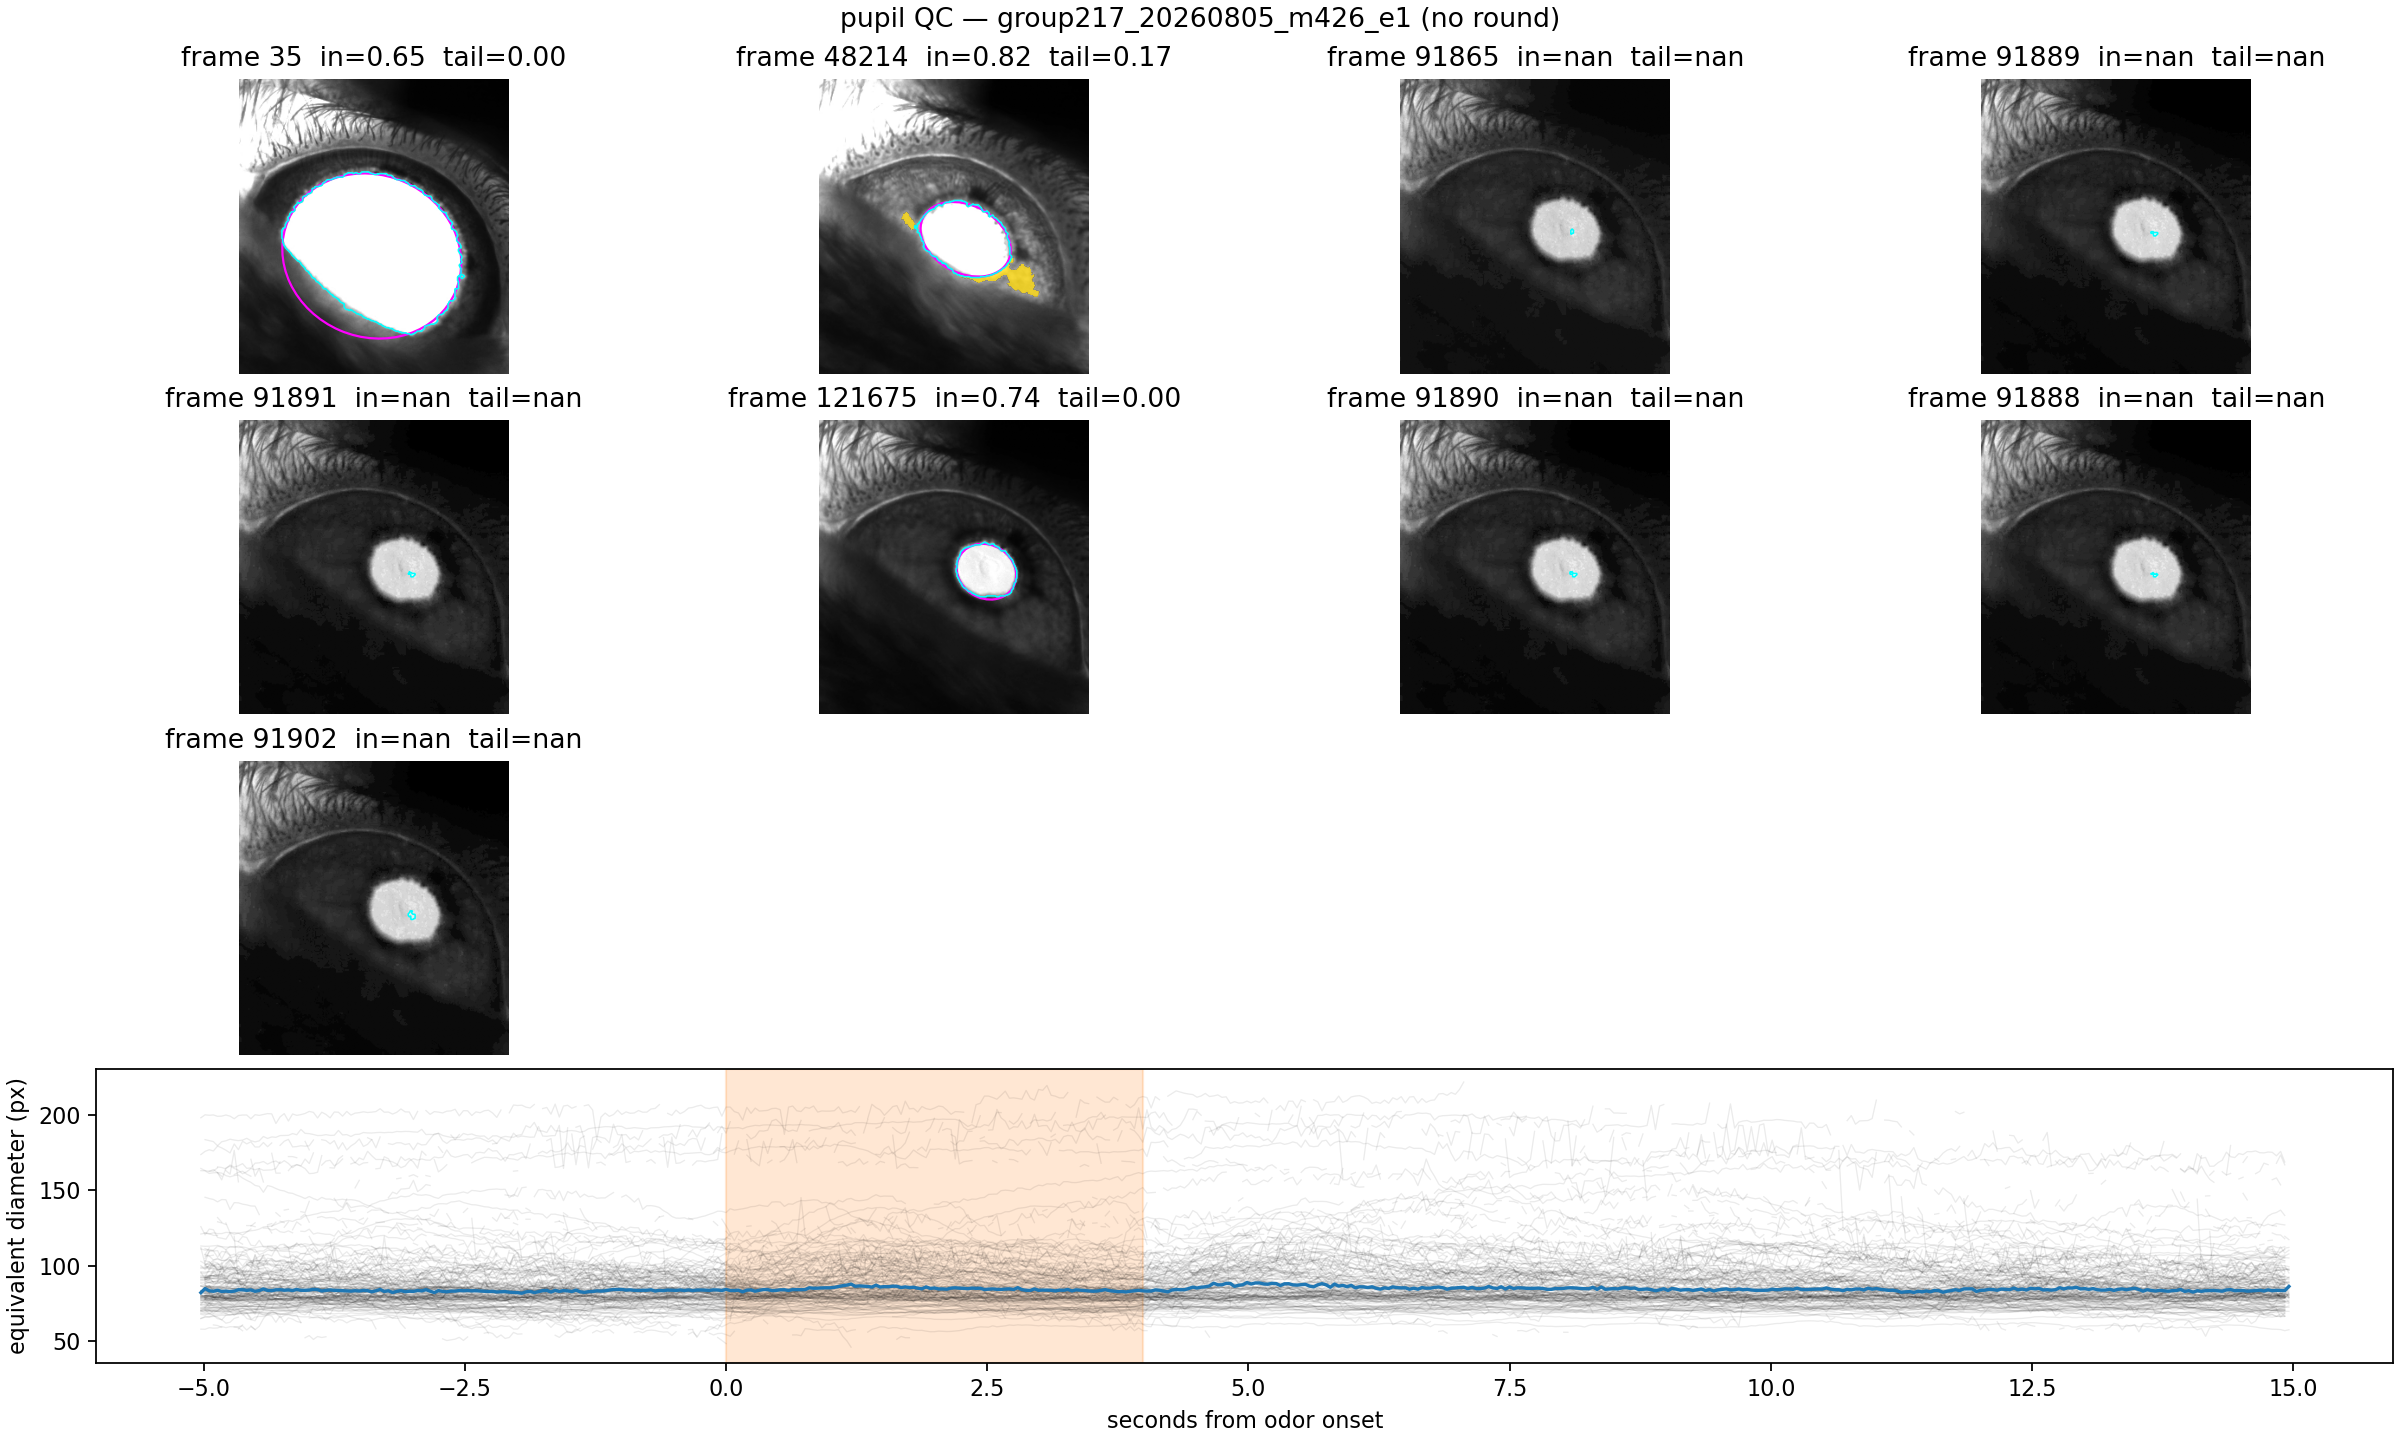

Worst trials by masked fraction:
  trial row 154, acq_id=21789, masked=80.3%, blink=80.1%, clipped=19.7%
  trial row 141, acq_id=21776, masked=79.9%, blink=79.7%, clipped=20.1%
  trial row 113, acq_id=21748, masked=78.3%, blink=78.1%, clipped=21.7%
  trial row  99, acq_id=21734, masked=77.3%, blink=77.1%, clipped=22.7%
  trial row 126, acq_id=21761, masked=76.9%, blink=76.7%, clipped=23.1%
  trial row 147, acq_id=21782, masked=74.5%, blink=74.3%, clipped=18.5%
  trial row  38, acq_id=21673, masked=74.1%, blink=73.9%, clipped=25.1%
  trial row  25, acq_id=21660, masked=72.9%, blink=72.7%, clipped=27.1%
  trial row 122, acq_id=21757, masked=72.5%, blink=72.3%, clipped=27.5%
  trial row 127, acq_id=21762, masked=71.1%, blink=70.9%, clipped=28.7%


ERROR:tornado.application:Uncaught exception GET /ws?id=0650616f-0eb2-4b88-bc09-ece3b2798597&parentId=1&origin=078754f2-5f12-4292-b43e-200d36396fd2&swVersion=6&extensionId=&platform=electron&vscode-resource-base-authority=vscode-resource.vscode-cdn.net&parentOrigin=vscode-file%3A%2F%2Fvscode-app&purpose=notebookRenderer (::1)
HTTPServerRequest(protocol='http', host='localhost:65487', method='GET', uri='/ws?id=0650616f-0eb2-4b88-bc09-ece3b2798597&parentId=1&origin=078754f2-5f12-4292-b43e-200d36396fd2&swVersion=6&extensionId=&platform=electron&vscode-resource-base-authority=vscode-resource.vscode-cdn.net&parentOrigin=vscode-file%3A%2F%2Fvscode-app&purpose=notebookRenderer', version='HTTP/1.1', remote_ip='::1')
Traceback (most recent call last):
  File "/Users/mosse/miniforge3/envs/caiman/lib/python3.12/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [ ]:
from IPython.display import Image, display

display(Image(filename=str(report['figure'])))

worst_trials = np.argsort(report['masked_fraction'])[::-1][:10]
print('Worst trials by masked fraction:')
for row in worst_trials:
    print(
        f"  trial row {row:3d}, acq_id={int(report['acq_id'][row])}, "
        f"masked={report['masked_fraction'][row]:.1%}, "
        f"blink={report['blink_fraction'][row]:.1%}, "
        f"clipped={report['clipped_fraction'][row]:.1%}"
    )

## 6. Respiration into the master aux file

The same sync file already opened above carries the thermocouple, so respiration needs no new input and no second pass over anything. Both products go into the aux HDF5 beside the pupil, cut by trial and joined on `acq_id`.

They sit on two different time bases, deliberately. `/respiration/filtered` is the bandpassed waveform at the full sync rate, with its own `filtered_time_s`: a breath is a few hundred milliseconds and the 2p frame grid cannot represent one, so decimating it to the imaging rate would alias the waveform rather than summarise it. `/respiration/rate` is the breath-smoothed instantaneous frequency, estimated at the full rate and *then* sampled onto the 2p frame grid, where it shares rows and columns with the pupil datasets and with `/traces/roi` in the processed round. Rate is the array to join against imaging; the waveform is there so the estimate can be checked against what it came from.


In [ ]:
# ---- respiration settings ----------------------------------------------
RESP_QUALITY_THRESHOLD = 5.0   # in-band/out-of-band power; module default
RESP_SMOOTH_BREATHS = 3        # breaths in the running median of the rate
RESP_MAX_MASKED = 0.20         # flag a trial masked beyond this fraction
RESP_EXCLUDE_FLAGGED = True    # leave flagged trials out of the odor figure
RESP_RATE_CLIP_HZ = (0.0, 20.0)

from analysis.session.respiration import (
    FILTER_BAND_HZ, bandpass, instantaneous_frequency, quality_report,
)
from analysis.session.sync import (
    acquisition_odor_windows, group_frames_into_acquisitions, pulse_intervals,
    read_channel,
)

resp_raw = read_channel(sync, 'respiration', column=0)
resp_frames = frame_onset_samples(sync)
resp_blocks = group_frames_into_acquisitions(resp_frames, rate_hz=sync.rate_hz)

acq_ids = np.asarray(session.acq_ids)
if len(resp_blocks) != acq_ids.size:
    raise ValueError(
        f'{len(resp_blocks)} acquisitions in the sync file but {acq_ids.size} '
        f'trials in the session. Respiration is cut per acquisition, so these '
        f'must correspond one to one -- set APPROVED_ONLY = False so no trial '
        f'is dropped from the session, or use a sync file for this experiment.'
    )
widths = {len(b) for b in resp_blocks}
if len(widths) != 1:
    raise ValueError(f'Acquisitions differ in length: {sorted(widths)}.')

n_trial, n_frame = len(resp_blocks), widths.pop()
resp_index = np.concatenate([np.searchsorted(resp_frames, b) for b in resp_blocks])
def _per_trial(values):
    return np.asarray(values)[resp_index].reshape(n_trial, n_frame).astype(np.float32)

# The rate is estimated once over the whole session at the sync rate and only
# then cut into trials. Estimating per trial would restart the breath history
# at every acquisition boundary and lose the breath that spans it.
resp_result = instantaneous_frequency(
    resp_raw, rate_hz=sync.rate_hz, at_s=resp_frames / sync.rate_hz,
    quality_threshold=RESP_QUALITY_THRESHOLD, smooth_breaths=RESP_SMOOTH_BREATHS,
)
resp_rate = _per_trial(resp_result['frequency_smooth_masked'])
resp_rate_unmasked = _per_trial(resp_result['frequency_smooth'])
resp_quality = _per_trial(resp_result['quality_at_s'])
resp_masked_fraction = np.mean(~np.isfinite(resp_rate), axis=1)
resp_flagged = resp_masked_fraction > RESP_MAX_MASKED

resp_pulses = pulse_intervals(read_channel(sync, 'odorPulse'), rate_hz=sync.rate_hz)
resp_windows = acquisition_odor_windows(resp_blocks, resp_pulses, rate_hz=sync.rate_hz)
if any(w is None for w in resp_windows):
    raise ValueError(f'{sum(w is None for w in resp_windows)} acquisitions have no odor pulse.')
resp_on_frames = np.array([w[0] for w in resp_windows])
resp_off_frames = np.array([w[1] for w in resp_windows])
resp_n_pre = int(np.median(resp_on_frames))

# ---- the waveform, at the full sync rate --------------------------------
# Each trial starts at its own first 2p frame onset and runs the same number of
# samples, so the rows share one time base. The length is the shortest
# acquisition's span, so no trial is padded or read past its own end.
resp_bandpassed = bandpass(resp_raw, rate_hz=sync.rate_hz)
resp_starts = np.array([b[0] for b in resp_blocks])
n_sample = int(min(b[-1] - b[0] for b in resp_blocks)) + 1
resp_filtered = np.stack(
    [resp_bandpassed[s:s + n_sample] for s in resp_starts]
).astype(np.float32)

# Odor onset moves by a sample or two between acquisitions; the shared time
# base uses the median and the spread is reported rather than absorbed.
resp_on_samples = np.array([b[w[0]] - b[0] for b, w in zip(resp_blocks, resp_windows)])
resp_off_samples = np.array([b[w[1]] - b[0] for b, w in zip(resp_blocks, resp_windows)])
resp_n_pre_sample = int(np.median(resp_on_samples))
resp_filtered_time_s = (np.arange(n_sample) - resp_n_pre_sample) / sync.rate_hz

print(f'{n_trial} trials')
print(f'  rate     {resp_rate.shape} on the 2p frame grid at {session.frame_rate:.3f} Hz')
print(f'  filtered {resp_filtered.shape} at the sync rate {sync.rate_hz:g} Hz '
      f'({n_sample / sync.rate_hz:.2f} s/trial, {resp_filtered.nbytes / 1e6:.0f} MB in memory)')
print(f'breaths: {resp_result["n_breaths"]:,}   session median '
      f'{np.nanmedian(resp_rate):.2f} Hz   range '
      f'{np.nanmin(resp_rate):.2f}-{np.nanmax(resp_rate):.2f} Hz')
print(f'quality kept: {resp_result["fraction_good"]:.1%} of windows at '
      f'threshold {RESP_QUALITY_THRESHOLD:g}')
print(f'masked per trial: median {np.median(resp_masked_fraction):.1%}   '
      f'flagged (> {RESP_MAX_MASKED:.0%}): {int(resp_flagged.sum())}/{n_trial}')
print(f'odor onset: frame {resp_n_pre} (spread {np.ptp(resp_on_frames)}), '
      f'sample {resp_n_pre_sample} (spread {np.ptp(resp_on_samples)})')
print('\n' + quality_report(resp_result['quality_at_s'],
                             thresholds=(0.5, 1.0, 2.0, 5.0, 10.0, 20.0)))


If the ladder above shows the chosen threshold discarding most of the session, lower `RESP_QUALITY_THRESHOLD` and re-run this cell before writing. The masking is what produces NaN in `/respiration/rate`, so it decides how much of the odor figure survives.


In [ ]:
AUX_PATH = OUT_DIR / f'group{GROUP_ID}_{session.exp_name}_pupil.h5'
if not AUX_PATH.exists():
    raise FileNotFoundError(
        f'{AUX_PATH} does not exist yet. Run the pupil extraction above first; '
        f'respiration is added to that file rather than replacing it.'
    )

import h5py

with h5py.File(AUX_PATH, 'r+') as f:
    # Join on acq_id rather than row position: position would silently
    # mismatch anywhere approval or a dropped trial shifted the rows.
    stored = f['trials/acq_id'][:]
    if not np.array_equal(np.asarray(stored, dtype=np.int64), acq_ids.astype(np.int64)):
        raise ValueError(
            f'{AUX_PATH.name} has different trial rows than this session '
            f'({stored.size} vs {acq_ids.size}). Re-run the pupil extraction '
            f'with the same APPROVED_ONLY setting before adding respiration.'
        )
    if int(f.attrs['n_frame']) != n_frame:
        raise ValueError(
            f'Aux file is on a {int(f.attrs["n_frame"])}-frame grid but '
            f'respiration produced {n_frame}.'
        )

    # Idempotent: re-running replaces the respiration group and never touches
    # the pupil datasets beside it.
    if 'respiration' in f:
        del f['respiration']
    r = f.create_group('respiration')

    # The waveform is the one array not on the frame grid, and it is large, so
    # it is chunked one trial per chunk -- reading a single trial back costs
    # one chunk rather than a stripe through all of them.
    r.create_dataset('filtered', data=resp_filtered, compression='gzip',
                     chunks=(1, resp_filtered.shape[1]))
    r['filtered'].attrs['units'] = 'a.u.'
    r['filtered'].attrs['sample_rate_hz'] = float(sync.rate_hz)
    r['filtered'].attrs['description'] = (
        f'Thermocouple bandpassed {FILTER_BAND_HZ[0]:g}-{FILTER_BAND_HZ[1]:g} Hz, at the '
        f'full sync rate ({sync.rate_hz:g} Hz), one row per trial starting at that '
        f'trial\'s first 2p frame onset. Its time axis is filtered_time_s, NOT the '
        f'file\'s frame-grid time_s.'
    )
    r.create_dataset('filtered_time_s', data=resp_filtered_time_s)
    r['filtered_time_s'].attrs['description'] = (
        'Seconds relative to the median odor onset, for /respiration/filtered.'
    )

    for name, data, units, note in (
        ('rate', resp_rate, 'Hz',
         f'Instantaneous frequency, running median over {RESP_SMOOTH_BREATHS} '
         f'breaths, NaN where quality < {RESP_QUALITY_THRESHOLD:g}.'),
        ('rate_unmasked', resp_rate_unmasked, 'Hz',
         'The same rate without the quality mask, so what was dropped is '
         'visible rather than inferred from a gap.'),
        ('quality', resp_quality, '',
         'In-band / out-of-band power of the raw thermocouple, per frame.'),
    ):
        r.create_dataset(name, data=data, compression='gzip')
        r[name].attrs['units'] = units
        r[name].attrs['description'] = note
    r.create_dataset('masked_fraction', data=resp_masked_fraction)
    r.create_dataset('flagged', data=resp_flagged.astype(np.int8))
    r['flagged'].attrs['description'] = (
        f'1 where more than {RESP_MAX_MASKED:.0%} of the trial is quality-masked.'
    )
    r.create_dataset('odor_on_frame', data=resp_on_frames)
    r.create_dataset('odor_off_frame', data=resp_off_frames)
    # Onset moves by only a frame between trials but by tens of milliseconds in
    # samples, which is a real fraction of a breath. Keep the per-trial values
    # so the waveform can be aligned exactly rather than on the median.
    r.create_dataset('odor_on_sample', data=resp_on_samples)
    r.create_dataset('odor_off_sample', data=resp_off_samples)
    r['odor_on_sample'].attrs['description'] = (
        'Odor onset as a sample offset into that row of /respiration/filtered. '
        'Use this for exact alignment rather than filtered_time_s, which uses '
        'the median onset.'
    )
    r.attrs['sync'] = Path(sync_path).name
    r.attrs['filter_band_hz'] = np.asarray(FILTER_BAND_HZ, dtype=float)
    r.attrs['quality_threshold'] = float(RESP_QUALITY_THRESHOLD)
    r.attrs['smooth_breaths'] = int(RESP_SMOOTH_BREATHS)
    r.attrs['max_masked_fraction'] = float(RESP_MAX_MASKED)
    r.attrs['n_breaths'] = int(resp_result['n_breaths'])
    r.attrs['median_hz'] = float(resp_result['median_hz'])
    r.attrs['session_fraction_good'] = float(resp_result['fraction_good'])
    r.attrs['n_flagged'] = int(resp_flagged.sum())
    r.attrs['sample_rate_hz'] = float(sync.rate_hz)
    r.attrs['frame_rate_hz'] = float(session.frame_rate)

print(f'Added /respiration to {AUX_PATH}')
with h5py.File(AUX_PATH, 'r') as f:
    for name in sorted(f['respiration']):
        item = f['respiration'][name]
        print(f'  respiration/{name:<16} {item.shape} {item.dtype}')


In [ ]:
# Sniff rate by odor, on the clipped axis so one noisy trial cannot rescale
# every panel. Pre and post are drawn separately: pooling them would average a
# manipulation away exactly where it is supposed to show.
odor_ids = np.asarray(session.odor_ids)
states = np.asarray(session.states)
odor_names = dict(zip(group.odors.odor_id.astype(int), group.odors.odor_name.astype(str)))

use = ~resp_flagged if RESP_EXCLUDE_FLAGGED else np.ones(n_trial, bool)
time_s = (np.arange(n_frame) - resp_n_pre) / session.frame_rate
odor_off_s = float(np.median(resp_off_frames - resp_on_frames)) / session.frame_rate
present = np.unique(odor_ids)
colours = {'pre': '#1f77b4', 'post': '#d62728'}

n_col = 4
n_row = int(np.ceil(len(present) / n_col))
fig, axes = plt.subplots(n_row, n_col, figsize=(4.0 * n_col, 2.7 * n_row),
                         squeeze=False, sharex=True, sharey=True)
for ax, odor in zip(axes.flat, present):
    ax.axvspan(0, odor_off_s, color='goldenrod', alpha=0.18, zorder=0)
    ax.axvline(0, color='0.3', lw=0.8, ls='--')
    for state in [s for s in ('pre', 'post') if s in set(states)]:
        rows = (odor_ids == odor) & (states == state) & use
        if not rows.any():
            continue
        block = resp_rate[rows]
        n_ok = np.sum(np.isfinite(block), axis=0)
        mean = np.nanmean(block, axis=0)
        sem = np.nanstd(block, axis=0) / np.sqrt(np.maximum(n_ok, 1))
        ax.fill_between(time_s, mean - sem, mean + sem,
                        color=colours[state], alpha=0.25, lw=0)
        ax.plot(time_s, mean, color=colours[state], lw=1.3,
                label=f'{state} (n={int(rows.sum())})')
    ax.set_title(odor_names.get(int(odor), f'odor {odor}'), fontsize=10)
    ax.set_ylim(*RESP_RATE_CLIP_HZ)
    ax.legend(fontsize=7, loc='upper right', frameon=False)
for ax in axes.flat[len(present):]:
    ax.axis('off')
for ax in axes[-1]:
    ax.set_xlabel('time from odor onset (s)')
for row in axes:
    row[0].set_ylabel('sniff rate (Hz)')
excluded = '' if not RESP_EXCLUDE_FLAGGED else f', {int(resp_flagged.sum())} flagged trials excluded'
fig.suptitle(f'group {GROUP_ID} {session.exp_name} -- sniff rate by odor '
             f'(y clipped {RESP_RATE_CLIP_HZ[0]:g}-{RESP_RATE_CLIP_HZ[1]:g} Hz{excluded})', y=1.0)
fig.tight_layout()
RESP_ODOR_FIG = OUT_DIR / f'group{GROUP_ID}_{session.exp_name}_respiration_by_odor.png'
fig.savefig(RESP_ODOR_FIG, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {RESP_ODOR_FIG}')
